# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import floor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
print('Everything is Imported Boss')

Everything is Imported Boss


# **Data exploration**

## **Load The Data**

In [2]:
file_path = input("Enter the File path baby: ")
df = pd.read_csv(file_path)
print("Data Loaded Baby")

Data Loaded Baby


## **Exploration**

In [3]:
print(f'The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} Duplicates')

The dataset have 31300 Rows and 10 columns with 297 Duplicates


In [4]:
df.head()

,performance_score,projects_completed,weekly_hours,training_hours_yr,salary_lakh,promotions,attendance_pct,satisfaction_score,years_experience,team_rating
0,94.76,17.22,48.89,83.99,28.95,3.66,98.05,4.15,9.63,5.00
1,96.52,14.63,50.99,89.41,31.55,3.80,100.00,4.26,10.92,4.25
2,94.25,16.58,43.65,69.36,22.53,3.22,100.00,4.69,10.70,4.41
3,92.81,16.61,47.45,103.12,29.68,3.43,94.48,3.89,6.46,4.42
4,87.55,14.32,48.99,77.03,22.24,3.09,94.71,3.84,10.07,4.47


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31300 entries, 0 to 31299
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   performance_score   30677 non-null  str    
 1   projects_completed  30673 non-null  float64
 2   weekly_hours        30672 non-null  float64
 3   training_hours_yr   30675 non-null  float64
 4   salary_lakh         30676 non-null  float64
 5   promotions          30671 non-null  float64
 6   attendance_pct      30671 non-null  float64
 7   satisfaction_score  30671 non-null  float64
 8   years_experience    30669 non-null  float64
 9   team_rating         30676 non-null  float64
dtypes: float64(9), str(1)
memory usage: 2.5 MB


In [6]:
df.describe()

,projects_completed,weekly_hours,training_hours_yr,salary_lakh,promotions,attendance_pct,satisfaction_score,years_experience,team_rating
count,30673.000000,30672.000000,30675.000000,30676.000000,30671.000000,30671.000000,30671.000000,30669.000000,30676.000000
mean,11.685913,47.174228,36.588396,18.049600,1.416822,86.175532,2.940625,5.475200,3.207590
std,5.136182,10.543072,27.065550,6.538687,1.122299,9.485082,1.026494,2.546372,0.976888
min,-1.330000,24.620000,-3.580000,-5.000000,0.000000,-10.000000,1.000000,0.000000,1.000000
25%,7.430000,39.260000,13.955000,13.140000,0.530000,79.000000,2.010000,3.570000,2.450000
50%,11.460000,44.540000,28.980000,16.480000,1.180000,88.050000,3.010000,5.390000,3.220000
75%,16.110000,54.560000,50.885000,21.450000,2.090000,94.250000,3.850000,7.260000,4.000000
max,25.410000,200.000000,116.620000,41.610000,6.610000,100.000000,8.000000,14.890000,5.000000


In [7]:
df.isna().sum()

performance_score     623
projects_completed    627
weekly_hours          628
training_hours_yr     625
salary_lakh           624
promotions            629
attendance_pct        629
satisfaction_score    629
years_experience      631
team_rating           624
dtype: int64

# **Data Cleaning**

## **Create Copy**

In [8]:
df_copy = df.copy()

## **DataType**

In [9]:
df_copy['performance_score'] = df_copy['performance_score'].replace('_err','',regex=True).astype('float')

## **Impossible Values**

In [10]:
df_copy.loc[df_copy['performance_score']>100,'performance_score'] = np.nan

below_zero = ['projects_completed','training_hours_yr','salary_lakh','attendance_pct']
for col in below_zero:
    df_copy.loc[df_copy[col]<0,col] = np.nan

## **outliers**

In [11]:
Outliers = ['weekly_hours','training_hours_yr','salary_lakh','years_experience']

for col in Outliers:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


## **Duplicates**

In [12]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 299
After: 0


## **NaN Values**

In [15]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())
Floor = ['projects_completed','promotions']
for col in Floor:
    df_copy[col] = df_copy[col].fillna(floor(df_copy[col].median()))
    
Round = ['performance_score',
         'weekly_hours',
         'training_hours_yr',
         'salary_lakh',
         'attendance_pct',
         'satisfaction_score',
         'years_experience',
         'team_rating']
for col in Round:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
print("NaN values in the Dataset After Cleaning is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
performance_score      625
projects_completed     624
weekly_hours           630
training_hours_yr      679
salary_lakh           1110
promotions             620
attendance_pct         625
satisfaction_score     620
years_experience       682
team_rating            620
dtype: int64
NaN values in the Dataset After Cleaning is: 
performance_score     0
projects_completed    0
weekly_hours          0
training_hours_yr     0
salary_lakh           0
promotions            0
attendance_pct        0
satisfaction_score    0
years_experience      0
team_rating           0
dtype: int64


# **Model**

In [16]:
features = df_copy.columns.tolist()

X = df_copy[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.describe().round(2)

,performance_score,projects_completed,weekly_hours,training_hours_yr,salary_lakh,promotions,attendance_pct,satisfaction_score,years_experience,team_rating
count,31001.00,31001.00,31001.00,31001.00,31001.00,31001.00,31001.00,31001.00,31001.00,31001.00
mean,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.31,-2.30,-2.19,-1.36,-2.24,-1.27,-3.79,-1.91,-2.19,-2.28
25%,-0.69,-0.81,-0.75,-0.82,-0.74,-0.78,-0.76,-0.91,-0.74,-0.76
50%,0.02,-0.07,-0.25,-0.28,-0.22,-0.22,0.20,0.07,-0.03,0.01
75%,0.63,0.85,0.69,0.51,0.50,0.59,0.85,0.88,0.70,0.80
max,1.90,2.70,2.96,2.62,2.66,4.68,1.48,4.98,2.94,1.85


## **Optimal K**

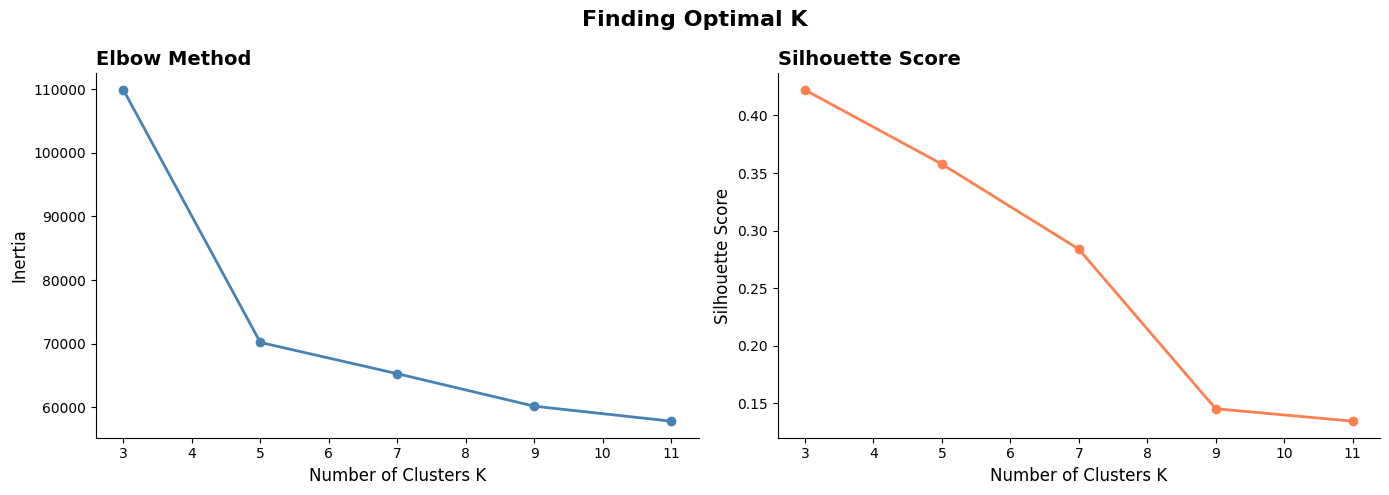

In [18]:
inertias = []
sil_scores = []
K_range = range(3, 12,2)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Number of Clusters K', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontweight='bold', fontsize=14, loc='left')
axes[0].spines[['right','top']].set_visible(False)

axes[1].plot(K_range, sil_scores, marker='o', color='coral', linewidth=2)
axes[1].set_xlabel('Number of Clusters K', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontweight='bold', fontsize=14, loc='left')
axes[1].spines[['right','top']].set_visible(False)

plt.suptitle('Finding Optimal K', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## **Train**

In [19]:
optimal_k = 5
model = KMeans(n_clusters=optimal_k,random_state=42,n_init=10)
model.fit(X_scaled)
print(f"Model trained with K={optimal_k} ✅")

Model trained with K=5 ✅


## **Labels**

In [20]:
# Add cluster labels back to original dataframe
df_copy['cluster'] = model.labels_

# How many rows in each cluster
print(df_copy['cluster'].value_counts().sort_index())

cluster
0    6998
1    4497
2    6989
3    7928
4    4589
Name: count, dtype: int64


In [22]:
# Compare clusters on every feature
cluster_profile = df_copy.groupby('cluster')[X.columns].mean().round(2)
cluster_profile

,performance_score,projects_completed,weekly_hours,training_hours_yr,salary_lakh,promotions,attendance_pct,satisfaction_score,years_experience,team_rating
cluster,,,,,,,,,,
0,48.51,5.08,36.17,8.51,12.12,0.29,74.39,1.83,3.07,2.03
1,71.87,10.02,42.13,39.71,15.06,0.99,90.95,3.49,3.37,3.50
2,91.53,17.87,47.94,78.41,26.48,2.95,96.74,4.18,7.86,4.48
3,65.05,13.92,61.70,20.10,17.93,1.50,82.06,2.21,6.00,2.80
4,72.12,10.03,42.09,39.65,15.15,1.02,90.84,3.48,6.54,3.48


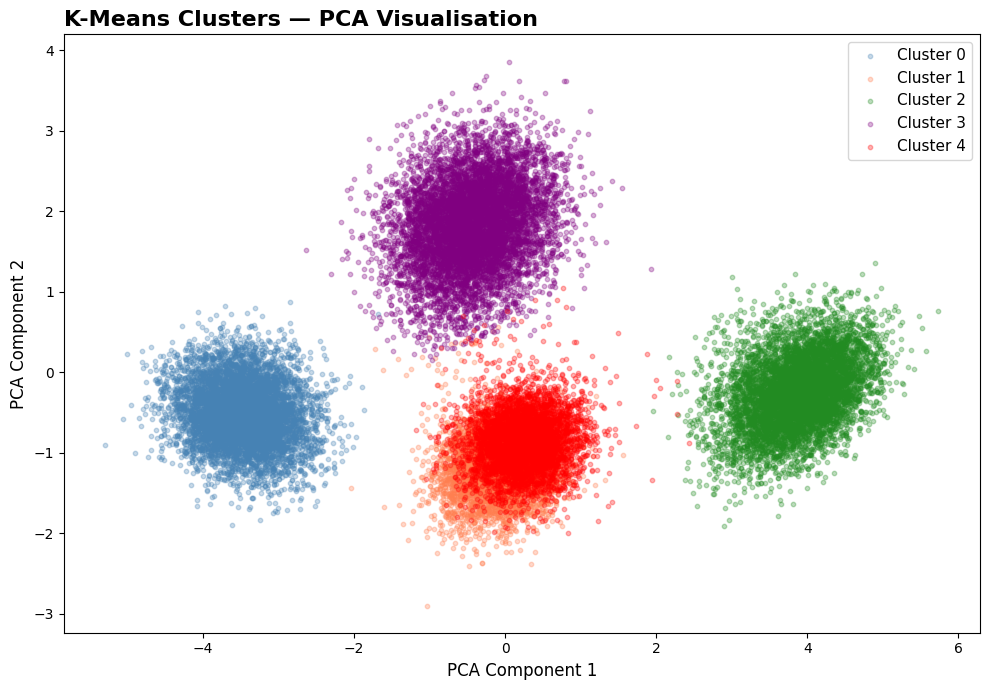

In [26]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
colors = ['steelblue', 'coral', 'forestgreen', 'purple', 'red']

for cluster_id in range(optimal_k):
    mask = model.labels_ == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[cluster_id], label=f'Cluster {cluster_id}',
                alpha=0.3, s=10)

plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.title('K-Means Clusters — PCA Visualisation',
          fontweight='bold', fontsize=16, loc='left')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

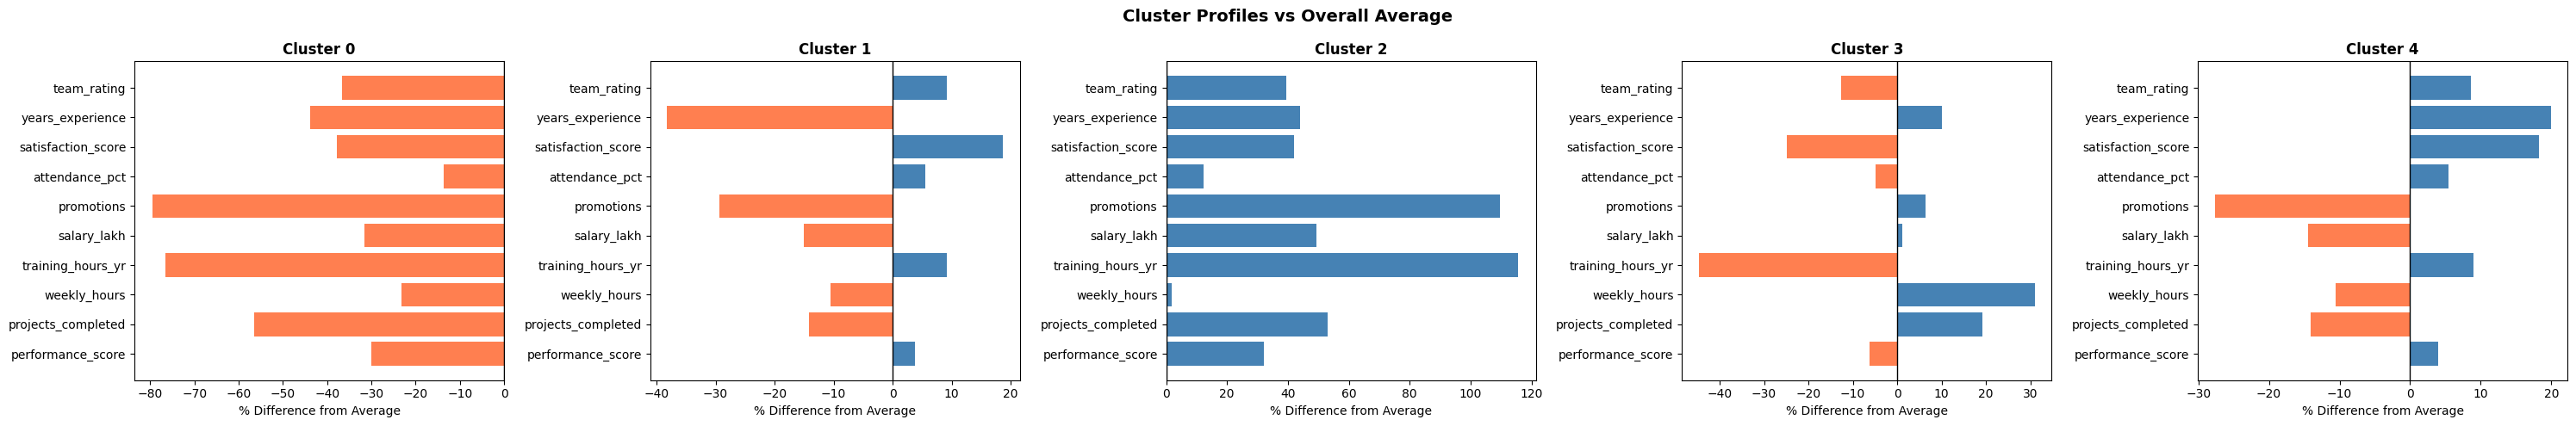

In [27]:
fig, axes = plt.subplots(1, optimal_k, figsize=(6*optimal_k, 5))

for i, ax in enumerate(axes):
    cluster_means = df_copy[df_copy['cluster']==i][X.columns].mean()
    overall_means = df_copy[X.columns].mean()
    diff = ((cluster_means - overall_means) / overall_means * 100).round(1)
    
    colors = ['coral' if v < 0 else 'steelblue' for v in diff]
    ax.barh(diff.index, diff.values, color=colors)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'Cluster {i}', fontweight='bold')
    ax.set_xlabel('% Difference from Average')

plt.suptitle('Cluster Profiles vs Overall Average',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()